# A Quick Introduction to Spatial Data Analysis and Manipulation with Python and pandas

Welcome to your introduction to **pandas**, the most widely used Python library for data analysis and manipulation. In this notebook, you will learn how to load, explore, clean, transform, and visualize tabular data — all using **real spatial datasets**.

We will work with three datasets throughout this notebook:

1. **USGS Earthquake Data** — A CSV feed of recent earthquakes recorded worldwide, including latitude, longitude, magnitude, and depth.
2. **IBTrACS Hurricane Data** — Tropical cyclone track observations from 2022 in the Western Hemisphere, including wind speed, pressure, and geographic coordinates.
3. **LA Crime Data** — Theft‑related crime records from the City of Los Angeles for the year 2020, including crime type, location, date, and area.

### Learning Objectives

By the end of this notebook you will be able to:

- Create pandas **Series** and **DataFrames** from scratch.
- Import data from CSV files and URLs using `pd.read_csv()`.
- Export data to CSV and Excel formats.
- Explore datasets using `.head()`, `.info()`, `.describe()`, and `.dtypes`.
- Select and filter data using column selection, boolean indexing, `.loc[]`, and `.iloc[]`.
- Manipulate data by handling missing values, creating new columns, and applying functions.
- Create quick visualizations directly from DataFrames.

Let's get started!

In [164]:
import datetime
print(f"Last updated: {datetime.datetime.now()}")

Last updated: 2026-02-25 23:15:13.421170


## Important Note — Setting the Working Directory

For this and many other notebooks in this course, you need to run the cell below to set your working directory. This ensures that Python can find any data files referenced throughout the notebook.

The code below detects the directory of your current ArcGIS Pro project (`.aprx`) and changes the working directory to match. If you are running this notebook outside of ArcGIS Pro (for example, in standalone Jupyter), you can replace the path with the folder where your data files are stored.

In [165]:
import arcpy
import os

# Get the full path of the current ArcGIS Pro project
aprx_path = arcpy.mp.ArcGISProject("CURRENT").filePath

# Extract the directory from the full file path
project_directory = os.path.dirname(aprx_path)
print(f"The current project directory is: {project_directory}")

# Change to the project directory so relative file paths work
os.chdir(project_directory)
print(f"Working directory set to: {os.getcwd()}")

The current project directory is: C:\courses\spa\spaWeek05
Working directory set to: C:\courses\spa\spaWeek05


## What is pandas?

[pandas](https://pandas.pydata.org/) is an open‑source Python library for **data analysis and manipulation**. The name comes from *"panel data"*, a term used in statistics for multi‑dimensional structured datasets.

If you work with tabular data in Python — whether it is a CSV of earthquake records, an Excel spreadsheet of field observations, or a database export of crime reports — you will almost certainly use pandas.

### Why is pandas so popular?

- **Easy I/O** — Read and write CSV, Excel, JSON, SQL, GeoJSON, and many more formats with a single function call.
- **Powerful data manipulation** — Filter rows, group and aggregate, merge tables, handle missing data, reshape, and pivot — all with concise, readable syntax.
- **Integration** — pandas is tightly integrated with NumPy, Matplotlib, scikit‑learn, geopandas, and virtually every other data‑science library in the Python ecosystem.
- **Performance** — Under the hood, pandas stores data in optimized NumPy arrays, so operations on millions of rows are fast.

In the context of **spatial analysis and GIS**, pandas is the foundation that libraries like **geopandas** build on. Master pandas first, and geopandas will feel natural.

## What does this notebook cover?

The pandas library is vast — there are often multiple ways to accomplish the same task. This notebook focuses on the **most fundamental and frequently used operations**, organized into six sections:

| Section | Topic |
|---|---|
| 0 | Importing pandas |
| 1 | Core datatypes — Series and DataFrame |
| 2 | Importing data from files and URLs |
| 3 | Exporting data |
| 4 | Describing and summarizing data |
| 5 | Viewing, selecting, and filtering data |
| 6 | Manipulating and transforming data |

These fundamentals are more than enough to handle the vast majority of data preparation tasks you will encounter in GIS and spatial programming.

## Where can I get help?

If you get stuck or want to do something this notebook does not cover, follow these steps:

1. **Try it yourself first.** pandas is very forgiving — experiment, run your code, read the error message, and adjust. Getting it wrong is part of the process.
2. **Search for it.** Chances are someone else has had the same question:
   - [pandas documentation](https://pandas.pydata.org/pandas-docs/stable/) — the definitive reference for every function and parameter.
   - [Stack Overflow](https://stackoverflow.com/) — the largest Q&A site for developers. Search for your error message or describe what you want to do.
   - [ChatGPT](https://chat.openai.com/) or [Claude](https://claude.ai/) — AI assistants are great at explaining code snippets. Try: *"Can you explain what this pandas code does?"* followed by your code.

A good search query looks like: **`pandas how to filter rows by column value`** or **`pandas convert column to datetime`**.

The more specific your search, the better your results.

## 0. Importing pandas

The first step in any pandas workflow is to **import the library**. By convention, pandas is imported with the alias `pd`:

```python
import pandas as pd
```

This means that every time you see `pd.` in code, it refers to the pandas library. This convention is used universally — in textbooks, tutorials, documentation, and production code — so it is important to follow it.

Let's import pandas and print the version number to confirm it is installed correctly.

In [166]:
import pandas as pd

# Print the version to confirm installation
print(f"pandas version: {pd.__version__}")

pandas version: 2.3.0


## 1. Core Datatypes — Series and DataFrame

pandas has two primary data structures:

| Structure | Dimensions | Analogy |
|---|---|---|
| **[`pd.Series`](https://pandas.pydata.org/docs/reference/api/pandas.Series.html)** | 1‑D (a single column) | A single column in a spreadsheet |
| **[`pd.DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)** | 2‑D (rows and columns) | An entire spreadsheet or database table |

A **DataFrame** is essentially a collection of **Series** that share the same index (row labels). Almost everything you do in pandas revolves around these two structures.

### Creating a Series

You create a Series by passing a Python list to `pd.Series()`. Each element in the list becomes a row in the Series.

In [167]:
# Creating a Series of land cover types
land_cover = pd.Series(["Forest", "Developed", "Open Water", "Agriculture"])
land_cover

0         Forest
1      Developed
2     Open Water
3    Agriculture
dtype: object

In [168]:
# Creating a Series of map colors
colors = pd.Series(["Green", "Red", "Blue", "Yellow"])
colors

0     Green
1       Red
2      Blue
3    Yellow
dtype: object

### Creating a DataFrame

You create a DataFrame by passing a **Python dictionary** to `pd.DataFrame()`. The dictionary keys become column names, and the values (which should be lists or Series of equal length) become the data in each column.

Let's combine our two Series into a DataFrame.

In [169]:
# Creating a DataFrame from our two Series
map_data = pd.DataFrame({"Land Cover": land_cover,
                         "Color": colors})
map_data

,Land Cover,Color
0,Forest,Green
1,Developed,Red
2,Open Water,Blue
3,Agriculture,Yellow


Notice how the dictionary keys (`"Land Cover"` and `"Color"`) became the **column headings** (shown in bold), and the values from each Series became the rows.

DataFrames can hold many different data types — strings, integers, floats, booleans, dates, and more. In fact, each column can have its own data type. We will see this when we load real datasets later.

### Exercise 0

Practice creating your own Series and DataFrame:

1. Create a `Series` of at least 3 **town or city names** (these can be real or made up).
2. Create a `Series` of **elevation values** (in meters) corresponding to each town. These should be numbers (integers or floats).
3. Combine your two Series into a **DataFrame** with appropriate column names.

**Important:** Both Series must have the same number of elements, or the DataFrame will raise an error.

Try it yourself first, then compare with the example solution in the cell below.

In [170]:
# Your code here


In [171]:
# --- Example solution ---

# Step 1: Create a Series of city names
cities = pd.Series(["Denver", "New Orleans", "Death Valley", "Jackson"])

# Step 2: Create a Series of elevations (meters)
elevations = pd.Series([1609, 2, -86, 91])

# Step 3: Combine into a DataFrame
city_data = pd.DataFrame({"City": cities,
                          "Elevation (m)": elevations})
city_data

,City,Elevation (m)
0,Denver,1609
1,New Orleans,2
2,Death Valley,-86
3,Jackson,91


## 2. Importing Data

Creating Series and DataFrames from scratch is useful for small examples, but in practice you will almost always **import data from an external source** such as:

- A **CSV file** (comma‑separated values) — the most common tabular data format.
- An **Excel file** (`.xlsx`).
- A **URL** pointing to a hosted CSV or API endpoint.
- A **database** via SQL.

pandas makes importing easy with functions like:

| Function | Use Case |
|---|---|
| `pd.read_csv()` | Read a CSV file from a local path or URL |
| `pd.read_excel()` | Read an Excel file |
| `pd.read_json()` | Read a JSON file or API response |
| `pd.read_sql()` | Read from a SQL database |

### Downloading Our Datasets

Below we download the **earthquake** and **hurricane** datasets and save them as local CSV files. We also load the **LA crime** dataset from a local file.

The earthquake data comes directly from the USGS real‑time CSV feed. The hurricane data comes from NOAA's IBTrACS archive via an ArcGIS Feature Service. The LA crime data (`LA_2020_Theft.csv`) should already be in your project folder.

> **Tip:** `pd.read_csv()` accepts both a local file path *and* a URL as input. This makes it very easy to work with data hosted online.

In [172]:
# --- Earthquake data from USGS (last 30 days) ---
earthquake_url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
eq = pd.read_csv(earthquake_url)
eq.to_csv("earthquakes.csv", index=False)

print(f"Earthquake data: {len(eq):,} rows, {len(eq.columns)} columns")
eq.head()

Earthquake data: 9,616 rows, 22 columns


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,7.3182,1.66,ml,13,208,1.048000,0.2769,...,2026-02-26T05:13:36.627Z,"67 km N of Rachel, Nevada",earthquake,NaN,1.2612,0.340,5.0,automatic,nn,nn
1,2026-02-26T04:59:03.922Z,51.556200,159.691500,10.0000,5.70,mww,63,156,1.603000,1.3500,...,2026-02-26T05:11:48.040Z,"176 km SSE of Vilyuchinsk, Russia",earthquake,8.26,1.9160,0.071,19.0,reviewed,us,us
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,6.7000,1.60,ml,8,282,0.100000,0.5000,...,2026-02-26T04:56:32.093Z,"26 km W of Central, Alaska",earthquake,11.20,4.3378,0.400,4.0,automatic,ak,ak
3,2026-02-26T04:24:59.410Z,38.823666,-122.765663,2.1500,1.00,md,16,121,0.007563,0.0100,...,2026-02-26T05:12:19.036Z,"4 km W of Cobb, CA",earthquake,0.27,0.4100,0.110,17.0,automatic,nc,nc
4,2026-02-26T04:22:52.820Z,38.910332,-123.250336,4.7700,1.79,md,16,96,0.048570,0.0500,...,2026-02-26T05:07:19.003Z,"15 km SE of Boonville, CA",earthquake,0.29,0.5500,0.150,14.0,automatic,nc,nc


In [173]:
# --- Hurricane data from IBTrACS via ArcGIS Feature Service (2022 Western Hemisphere) ---
import geopandas as gpd

hurricane_service_url = (
    "https://services2.arcgis.com/FiaPA4ga0iQKduv3/ArcGIS/rest/services/"
    "IBTrACS_ALL_list_v04r00_lines_1/FeatureServer/0/query?"
    "where=OBJECTID+%3E+0+AND+year%3D2022+AND+LON%3C0+AND+LAT%3E0"
    "&outFields=*&returnGeometry=true&f=pgeojson"
)

hurricane_gdf = gpd.read_file(hurricane_service_url)
hur = pd.DataFrame(hurricane_gdf, copy=True)
hur.to_csv("hurricanes.csv", index=False)

print(f"Hurricane data: {len(hur):,} rows, {len(hur.columns)} columns")
hur.head()

Hurricane data: 1,939 rows, 15 columns


,OBJECTID,SID,BASIN,SUBBASIN,NAME,NATURE,year,month,day,Hurricane_Date,LAT,LON,USA_WIND,USA_PRES,geometry
0,688160,2022148N13263,EP,MM,Agatha,DS,2022,5,27,1653710400000,12.9,-97.3,25,1008,"LINESTRING (-97.30005 12.9, -97.5 12.8)"
1,688161,2022148N13263,EP,MM,Agatha,DS,2022,5,27,1653710400000,12.8,-97.5,28,1007,"LINESTRING (-97.5 12.8, -97.69995 12.8)"
2,688162,2022148N13263,EP,MM,Agatha,TS,2022,5,28,1653796800000,12.8,-97.7,30,1006,"LINESTRING (-97.69995 12.8, -97.80005 12.8)"
3,688163,2022148N13263,EP,MM,Agatha,TS,2022,5,28,1653796800000,12.8,-97.8,33,1005,"LINESTRING (-97.80005 12.8, -97.90002 12.9)"
4,688164,2022148N13263,EP,MM,Agatha,TS,2022,5,28,1653796800000,12.9,-97.9,35,1004,"LINESTRING (-97.90002 12.9, -97.90002 13)"


### Loading from Local Files

Once data has been saved locally, you can reload it at any time without needing an internet connection. This is the more common workflow — download once, then work from the local copy.

A common convention is to name your main DataFrame `df` (short for DataFrame). You will see this in many tutorials and Stack Overflow answers. However, when working with multiple datasets it is better to use descriptive names like `eq` or `hur`.

In [174]:
# Reload from local CSV files
eq = pd.read_csv("earthquakes.csv")
hur = pd.read_csv("hurricanes.csv")

print(f"eq  : {eq.shape[0]:,} rows x {eq.shape[1]} columns")
print(f"hur : {hur.shape[0]:,} rows x {hur.shape[1]} columns")

eq  : 9,616 rows x 22 columns
hur : 1,939 rows x 15 columns


## 3. Exporting Data

After you have loaded, explored, or modified your data, you will often want to **save the results** so they can be shared, archived, or loaded into another tool.

pandas provides export methods that mirror the import functions:

| Method | Output Format |
|---|---|
| `.to_csv()` | Comma‑separated values |
| `.to_excel()` | Excel workbook (`.xlsx`) |
| `.to_json()` | JSON |

The most important parameter is the **filename** (including the extension). Setting `index=False` prevents pandas from writing the row numbers as an extra column, which is usually what you want.

Let's try exporting our earthquake data to an Excel file.

In [175]:
# Export to Excel
eq.to_excel("earthquakes_export.xlsx", index=False)
print("Saved earthquakes_export.xlsx")

Saved earthquakes_export.xlsx


In [176]:
# Export to CSV
eq.to_csv("earthquakes_export.csv", index=False)
print("Saved earthquakes_export.csv")

Saved earthquakes_export.csv


## Exercise 1 — Importing and Exporting the LA Crime Dataset

Now it's your turn to practice importing and exporting data.

The file **`LA_2020_Theft.csv`** contains anonymized theft‑related crime records from the City of Los Angeles for the year 2020. Each row represents a single reported crime and includes fields such as the date, time, crime type, area name, victim age, and geographic coordinates.

**Tasks:**

1. Use `pd.read_csv()` to import `LA_2020_Theft.csv` into a DataFrame. Store it in a variable with a descriptive name (e.g., `crimes` or `la_theft`).
2. Use `.head()` to preview the first few rows.
3. Use `.to_csv()` to export the DataFrame to a new file called `la_theft_copy.csv`.

**Note:** Make sure the CSV file is in the same folder as your notebook, or provide the full file path.

In [177]:
# Your code here — import LA_2020_Theft.csv


In [178]:
# Your code here — export to a new CSV


## 4. Describing and Summarizing Data

After importing a dataset, the very first thing you should do is **explore it**. You need to understand what columns are available, what data types they contain, whether there are missing values, and what the general shape of the data looks like.

pandas provides several built‑in methods that make this quick and easy:

| Method | What It Shows |
|---|---|
| `.head(n)` | First *n* rows (default 5) |
| `.tail(n)` | Last *n* rows |
| `.shape` | Tuple of (rows, columns) |
| `.dtypes` | Data type of each column |
| `.info()` | Column names, non‑null counts, data types, and memory usage |
| `.describe()` | Summary statistics (count, mean, std, min, max, quartiles) for numeric columns |
| `.columns` | List of all column names |
| `.index` | The row index |
| `len(df)` | Number of rows |

Let's try each one on our earthquake DataFrame.

In [179]:
# Preview the data
eq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,7.3182,1.66,ml,13,208,1.048000,0.2769,...,2026-02-26T05:13:36.627Z,"67 km N of Rachel, Nevada",earthquake,NaN,1.2612,0.340,5.0,automatic,nn,nn
1,2026-02-26T04:59:03.922Z,51.556200,159.691500,10.0000,5.70,mww,63,156,1.603000,1.3500,...,2026-02-26T05:11:48.040Z,"176 km SSE of Vilyuchinsk, Russia",earthquake,8.26,1.9160,0.071,19.0,reviewed,us,us
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,6.7000,1.60,ml,8,282,0.100000,0.5000,...,2026-02-26T04:56:32.093Z,"26 km W of Central, Alaska",earthquake,11.20,4.3378,0.400,4.0,automatic,ak,ak
3,2026-02-26T04:24:59.410Z,38.823666,-122.765663,2.1500,1.00,md,16,121,0.007563,0.0100,...,2026-02-26T05:12:19.036Z,"4 km W of Cobb, CA",earthquake,0.27,0.4100,0.110,17.0,automatic,nc,nc
4,2026-02-26T04:22:52.820Z,38.910332,-123.250336,4.7700,1.79,md,16,96,0.048570,0.0500,...,2026-02-26T05:07:19.003Z,"15 km SE of Boonville, CA",earthquake,0.29,0.5500,0.150,14.0,automatic,nc,nc


### `.dtypes` — Column Data Types

The `.dtypes` attribute shows the data type of every column. Common types you will see include:

- `float64` — decimal numbers (e.g., magnitude, latitude)
- `int64` — whole numbers
- `object` — usually strings (text), but can also be mixed types

Notice that the `time` column is listed as `object` rather than a datetime type. This is very common when loading CSVs — pandas does not automatically parse date strings. We will fix this later.

In [180]:
eq.dtypes

time                object
latitude           float64
longitude          float64
depth              float64
mag                float64
magType             object
nst                  int64
gap                  int64
dmin               float64
rms                float64
net                 object
id                  object
updated             object
place               object
type                object
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status              object
locationSource      object
magSource           object
dtype: object

### `.describe()` — Quick Statistical Summary

The `.describe()` method calculates summary statistics for every numeric column. This is one of the fastest ways to spot potential issues in your data:

- Is the **min** or **max** of a column unreasonable? (e.g., a negative depth might indicate a data entry error)
- Is the **mean** far from the **50th percentile (median)**? If so, the data may be skewed.
- Is the **count** lower than the total number of rows? If so, that column has missing values.

In [181]:
eq.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,9616.000000,9616.000000,9616.000000,9615.000000,9616.000000,9616.000000,9602.000000,9616.000000,9123.000000,9540.000000,9580.000000,9613.000000
mean,40.008837,-112.222072,20.936972,1.710879,26.533798,106.470258,0.435503,0.314094,2.692743,2.743291,0.191228,17.783834
std,17.546746,65.374059,50.067969,1.207662,22.954070,66.314164,1.384157,0.302967,4.707990,5.205204,0.119491,26.039082
min,-67.468600,-179.958100,-3.480000,-1.540000,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.238417,-149.775250,3.647500,0.950000,12.000000,59.000000,0.025157,0.100000,0.290000,0.530000,0.103226,7.000000
50%,38.794666,-122.720749,7.465300,1.600000,20.000000,84.000000,0.098565,0.180000,0.657662,1.049413,0.177000,12.000000
75%,55.410375,-110.957958,13.985000,2.100000,33.000000,138.000000,0.300000,0.500000,3.800000,2.765625,0.237743,19.000000
max,69.505000,179.961900,654.627000,7.100000,295.000000,358.000000,33.227000,2.200000,124.600000,115.700000,2.100000,562.000000


### `.info()` — Structure Overview

The `.info()` method gives you a compact summary including:

- The total number of entries (rows).
- Each column's name, non‑null count, and data type.
- Total memory usage.

If a column's non‑null count is **less than** the total number of entries, that column has missing values. This is very important to check before performing analysis.

In [182]:
eq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9616 entries, 0 to 9615
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             9616 non-null   object 
 1   latitude         9616 non-null   float64
 2   longitude        9616 non-null   float64
 3   depth            9616 non-null   float64
 4   mag              9615 non-null   float64
 5   magType          9615 non-null   object 
 6   nst              9616 non-null   int64  
 7   gap              9616 non-null   int64  
 8   dmin             9602 non-null   float64
 9   rms              9616 non-null   float64
 10  net              9616 non-null   object 
 11  id               9616 non-null   object 
 12  updated          9616 non-null   object 
 13  place            9616 non-null   object 
 14  type             9616 non-null   object 
 15  horizontalError  9123 non-null   float64
 16  depthError       9540 non-null   float64
 17  magError      

### Aggregation Methods — `.mean()`, `.sum()`, `.max()`, `.min()`

You can call statistical methods directly on a DataFrame or on an individual Series (column):

- **On a DataFrame:** returns the statistic for every numeric column.
- **On a Series:** returns a single value.

When calling on a DataFrame, use `numeric_only=True` to avoid errors from non‑numeric columns.

In [183]:
# Mean of all numeric columns
eq.mean(numeric_only=True)

latitude            40.008837
longitude         -112.222072
depth               20.936972
mag                  1.710879
nst                 26.533798
gap                106.470258
dmin                 0.435503
rms                  0.314094
horizontalError      2.692743
depthError           2.743291
magError             0.191228
magNst              17.783834
dtype: float64

In [184]:
# Mean of a single column
print(f"Average earthquake magnitude: {eq['mag'].mean():.2f}")
print(f"Maximum earthquake depth: {eq['depth'].max():.1f} km")

Average earthquake magnitude: 1.71
Maximum earthquake depth: 654.6 km


In [185]:
# Sum of a single column (total seismic energy proxy)
print(f"Sum of all magnitudes: {eq['mag'].sum():.1f}")

Sum of all magnitudes: 16450.1


### `.columns` and `.index`

The `.columns` attribute returns the names of all columns as an Index object. You can convert it to a list if needed. The `.index` attribute returns the row labels — by default these are integers starting at 0.

In [186]:
# Column names
print("Columns:")
print(eq.columns.tolist())

Columns:
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


In [187]:
# Index and length
print(f"Index: {eq.index}")
print(f"Number of rows: {len(eq):,}")

Index: RangeIndex(start=0, stop=9616, step=1)
Number of rows: 9,616


## 5. Viewing, Selecting, and Filtering Data

Once you understand the structure of your data, the next step is to **select specific rows, columns, or subsets** for analysis. pandas gives you many powerful tools for this:

| Method / Syntax | What It Does |
|---|---|
| `df.head(n)` | First *n* rows |
| `df.tail(n)` | Last *n* rows |
| `df['column']` | Select a single column (returns a Series) |
| `df[['col1', 'col2']]` | Select multiple columns (returns a DataFrame) |
| `df.loc[label]` | Select by **row label** (or boolean condition) |
| `df.iloc[position]` | Select by **integer position** |
| `df[df['col'] > value]` | **Boolean indexing** — filter rows by a condition |
| `df.groupby('col')` | Group rows by column values for aggregation |
| `pd.crosstab()` | Cross‑tabulate two categorical columns |

Let's work through each of these.

### `.head()` and `.tail()`

These are the simplest viewing methods. By default they show 5 rows, but you can pass any integer.

In [188]:
# First 5 rows
eq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,7.3182,1.66,ml,13,208,1.048000,0.2769,...,2026-02-26T05:13:36.627Z,"67 km N of Rachel, Nevada",earthquake,NaN,1.2612,0.340,5.0,automatic,nn,nn
1,2026-02-26T04:59:03.922Z,51.556200,159.691500,10.0000,5.70,mww,63,156,1.603000,1.3500,...,2026-02-26T05:11:48.040Z,"176 km SSE of Vilyuchinsk, Russia",earthquake,8.26,1.9160,0.071,19.0,reviewed,us,us
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,6.7000,1.60,ml,8,282,0.100000,0.5000,...,2026-02-26T04:56:32.093Z,"26 km W of Central, Alaska",earthquake,11.20,4.3378,0.400,4.0,automatic,ak,ak
3,2026-02-26T04:24:59.410Z,38.823666,-122.765663,2.1500,1.00,md,16,121,0.007563,0.0100,...,2026-02-26T05:12:19.036Z,"4 km W of Cobb, CA",earthquake,0.27,0.4100,0.110,17.0,automatic,nc,nc
4,2026-02-26T04:22:52.820Z,38.910332,-123.250336,4.7700,1.79,md,16,96,0.048570,0.0500,...,2026-02-26T05:07:19.003Z,"15 km SE of Boonville, CA",earthquake,0.29,0.5500,0.150,14.0,automatic,nc,nc


In [189]:
# First 10 rows
eq.head(10)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,7.3182,1.66,ml,13,208,1.048000,0.2769,...,2026-02-26T05:13:36.627Z,"67 km N of Rachel, Nevada",earthquake,NaN,1.261200,0.340,5.0,automatic,nn,nn
1,2026-02-26T04:59:03.922Z,51.556200,159.691500,10.0000,5.70,mww,63,156,1.603000,1.3500,...,2026-02-26T05:11:48.040Z,"176 km SSE of Vilyuchinsk, Russia",earthquake,8.26,1.916000,0.071,19.0,reviewed,us,us
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,6.7000,1.60,ml,8,282,0.100000,0.5000,...,2026-02-26T04:56:32.093Z,"26 km W of Central, Alaska",earthquake,11.20,4.337800,0.400,4.0,automatic,ak,ak
3,2026-02-26T04:24:59.410Z,38.823666,-122.765663,2.1500,1.00,md,16,121,0.007563,0.0100,...,2026-02-26T05:12:19.036Z,"4 km W of Cobb, CA",earthquake,0.27,0.410000,0.110,17.0,automatic,nc,nc
4,2026-02-26T04:22:52.820Z,38.910332,-123.250336,4.7700,1.79,md,16,96,0.048570,0.0500,...,2026-02-26T05:07:19.003Z,"15 km SE of Boonville, CA",earthquake,0.29,0.550000,0.150,14.0,automatic,nc,nc
5,2026-02-26T04:17:28.718Z,32.086000,-102.028000,4.3081,1.30,ml,40,49,0.100000,0.5000,...,2026-02-26T05:00:31.158Z,"10 km NNE of Midland, Texas",earthquake,0.00,0.864171,0.200,25.0,automatic,tx,tx
6,2026-02-26T03:59:50.190Z,38.822498,-122.811501,2.5800,1.04,md,20,52,0.018390,0.0200,...,2026-02-26T04:42:20.888Z,"7 km NW of The Geysers, CA",earthquake,0.25,0.430000,0.220,21.0,automatic,nc,nc
7,2026-02-26T03:59:04.300Z,38.821167,-122.813164,3.8800,0.83,md,8,82,0.017190,0.0100,...,2026-02-26T04:17:21.655Z,"7 km NW of The Geysers, CA",earthquake,0.61,2.770000,0.280,8.0,automatic,nc,nc
8,2026-02-26T03:58:46.920Z,38.822334,-122.810669,2.6900,2.10,md,40,49,0.018710,0.0500,...,2026-02-26T04:07:20.594Z,"7 km NW of The Geysers, CA",earthquake,0.18,0.320000,0.140,40.0,automatic,nc,nc
9,2026-02-26T03:49:12.339Z,59.832000,-152.298000,94.6000,2.40,ml,40,88,0.400000,0.4000,...,2026-02-26T04:15:14.040Z,"26 km WNW of Anchor Point, Alaska",earthquake,4.60,2.899200,0.200,4.0,automatic,ak,ak


In [190]:
# Last 5 rows
eq.tail()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
9611,2026-01-27T05:43:34.549Z,32.105,-101.898,8.9111,1.1,ml,51,58,0.1,0.1,...,2026-01-27T13:28:23.260Z,"10 km WSW of Stanton, Texas",earthquake,0.276193,0.701123,0.0,7.0,reviewed,tx,tx
9612,2026-01-27T05:33:33.586Z,64.241,-149.923,6.2000,1.9,ml,23,66,0.5,0.9,...,2026-01-27T20:29:09.645Z,"35 km W of Clear, Alaska",earthquake,2.700000,1.943000,0.2,13.0,reviewed,ak,ak
9613,2026-01-27T05:25:14.153Z,51.411,-176.166,21.6000,2.4,ml,11,284,0.5,0.4,...,2026-01-27T20:23:44.905Z,"60 km SSE of Adak, Alaska",earthquake,9.500000,6.272900,0.2,6.0,reviewed,ak,ak
9614,2026-01-27T05:18:26.093Z,60.474,-147.602,5.5000,1.8,ml,20,78,0.5,0.7,...,2026-01-27T20:22:21.900Z,"50 km NNE of Chenega, Alaska",earthquake,4.800000,4.078200,0.1,8.0,reviewed,ak,ak
9615,2026-01-27T05:16:19.342Z,61.222,-140.753,3.5000,2.0,ml,18,65,0.4,0.7,...,2026-01-27T22:05:28.165Z,"118 km ESE of McCarthy, Alaska",earthquake,3.600000,2.963800,0.2,13.0,reviewed,ak,ak


### `.loc[]` vs `.iloc[]` — Label‑Based vs Position‑Based Selection

This is one of the most important distinctions in pandas:

- **`.loc[]`** selects by **label** (the index value). If your index is the default integers 0, 1, 2, …, then `.loc[3]` returns the row whose *label* is 3.
- **`.iloc[]`** selects by **integer position** (like a Python list). `.iloc[3]` always returns the 4th row (0‑indexed), regardless of what the index labels are.

When the index is the default sequential integers, `.loc[]` and `.iloc[]` give the same result. But when the index is shuffled, reset, or set to a non‑integer column, the difference matters.

Let's see this with a small example first.

In [191]:
# Create a Series with a non-sequential index
cities = pd.Series(["Los Angeles", "Houston", "Phoenix", "Memphis", "Denver", "Portland"],
                    index=[0, 3, 9, 8, 67, 3])
cities

0     Los Angeles
3         Houston
9         Phoenix
8         Memphis
67         Denver
3        Portland
dtype: object

In [192]:
# .loc selects by INDEX LABEL
# There are two rows with label 3 — both are returned
cities.loc[3]

3     Houston
3    Portland
dtype: object

In [193]:
# .iloc selects by POSITION
# Position 3 (the 4th element) is "Memphis"
cities.iloc[3]

'Memphis'

Now let's try `.loc[]` and `.iloc[]` on the earthquake DataFrame.

In [194]:
# Select the row at index label 3
eq.loc[3]

time               2026-02-26T04:24:59.410Z
latitude                          38.823666
longitude                       -122.765663
depth                                  2.15
mag                                     1.0
magType                                  md
nst                                      16
gap                                     121
dmin                               0.007563
rms                                    0.01
net                                      nc
id                               nc75319062
updated            2026-02-26T05:12:19.036Z
place                    4 km W of Cobb, CA
type                             earthquake
horizontalError                        0.27
depthError                             0.41
magError                               0.11
magNst                                 17.0
status                            automatic
locationSource                           nc
magSource                                nc
Name: 3, dtype: object

In [195]:
# Select the row at position 3 (same result here because the index is sequential)
eq.iloc[3]

time               2026-02-26T04:24:59.410Z
latitude                          38.823666
longitude                       -122.765663
depth                                  2.15
mag                                     1.0
magType                                  md
nst                                      16
gap                                     121
dmin                               0.007563
rms                                    0.01
net                                      nc
id                               nc75319062
updated            2026-02-26T05:12:19.036Z
place                    4 km W of Cobb, CA
type                             earthquake
horizontalError                        0.27
depthError                             0.41
magError                               0.11
magNst                                 17.0
status                            automatic
locationSource                           nc
magSource                                nc
Name: 3, dtype: object

In [196]:
# Slicing: get the first 4 rows
eq.iloc[:4]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,7.3182,1.66,ml,13,208,1.048000,0.2769,...,2026-02-26T05:13:36.627Z,"67 km N of Rachel, Nevada",earthquake,NaN,1.2612,0.340,5.0,automatic,nn,nn
1,2026-02-26T04:59:03.922Z,51.556200,159.691500,10.0000,5.70,mww,63,156,1.603000,1.3500,...,2026-02-26T05:11:48.040Z,"176 km SSE of Vilyuchinsk, Russia",earthquake,8.26,1.9160,0.071,19.0,reviewed,us,us
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,6.7000,1.60,ml,8,282,0.100000,0.5000,...,2026-02-26T04:56:32.093Z,"26 km W of Central, Alaska",earthquake,11.20,4.3378,0.400,4.0,automatic,ak,ak
3,2026-02-26T04:24:59.410Z,38.823666,-122.765663,2.1500,1.00,md,16,121,0.007563,0.0100,...,2026-02-26T05:12:19.036Z,"4 km W of Cobb, CA",earthquake,0.27,0.4100,0.110,17.0,automatic,nc,nc


In [197]:
# Select all rows for a specific column using .loc
eq.loc[:, "mag"]  # ":" means "all rows"

0       1.66
1       5.70
2       1.60
3       1.00
4       1.79
        ... 
9611    1.10
9612    1.90
9613    2.40
9614    1.80
9615    2.00
Name: mag, Length: 9616, dtype: float64

**When to use which:**

- Use **`.loc[]`** when you want to select rows and columns **by their labels** or by a **boolean condition** (e.g., all rows where magnitude > 4.0).
- Use **`.iloc[]`** when you want to select rows and columns **by their integer position** (e.g., the first 10 rows, or every other row).

In practice, you will use column selection and boolean indexing far more often than `.loc` or `.iloc` directly.

### Selecting Columns

The simplest way to select a column is with bracket notation: `df['column_name']`. This returns a **Series**.

To select multiple columns, pass a **list** of column names inside the brackets: `df[['col1', 'col2']]`. This returns a **DataFrame**.

In [198]:
# Select a single column (returns a Series)
eq['place']

0               67 km N of Rachel, Nevada
1       176 km SSE of Vilyuchinsk, Russia
2              26 km W of Central, Alaska
3                      4 km W of Cobb, CA
4               15 km SE of Boonville, CA
                      ...                
9611          10 km WSW of Stanton, Texas
9612             35 km W of Clear, Alaska
9613            60 km SSE of Adak, Alaska
9614         50 km NNE of Chenega, Alaska
9615       118 km ESE of McCarthy, Alaska
Name: place, Length: 9616, dtype: object

In [199]:
# Select multiple columns (returns a DataFrame)
eq[['time', 'latitude', 'longitude', 'mag']].head()

,time,latitude,longitude,mag
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,1.66
1,2026-02-26T04:59:03.922Z,51.556200,159.691500,5.70
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,1.60
3,2026-02-26T04:24:59.410Z,38.823666,-122.765663,1.00
4,2026-02-26T04:22:52.820Z,38.910332,-123.250336,1.79


### Boolean Indexing — Filtering Rows by a Condition

**Boolean indexing** is one of the most powerful features in pandas. It lets you filter a DataFrame to only the rows that meet a certain condition.

The syntax is: `df[df['column'] <operator> value]`

For example:
- `eq[eq['mag'] > 4.0]` — all earthquakes with magnitude greater than 4.0
- `eq[eq['magType'] == 'ml']` — all earthquakes where the magnitude type is "ml"

This works because `eq['mag'] > 4.0` produces a Series of `True`/`False` values, and pandas keeps only the rows where the value is `True`.

In [200]:
# Filter: earthquakes deeper than 100 km
deep_quakes = eq[eq['depth'] > 100]
print(f"Earthquakes deeper than 100 km: {len(deep_quakes):,}")
deep_quakes.head()

Earthquakes deeper than 100 km: 424


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
12,2026-02-26T03:34:21.757Z,-6.1598,128.6346,328.589,4.4,mb,28,63,2.060,0.80,...,2026-02-26T03:57:44.040Z,"277 km S of Ambon, Indonesia",earthquake,8.35,7.5010,0.108,25.0,reviewed,us,us
21,2026-02-26T02:49:04.986Z,-20.6290,-176.3046,231.867,5.2,mww,29,117,5.820,1.62,...,2026-02-26T03:09:12.040Z,"120 km WNW of Houma, Tonga",earthquake,9.94,7.6860,0.093,11.0,reviewed,us,us
25,2026-02-26T01:31:27.822Z,58.2220,-155.9870,153.000,2.8,ml,97,68,0.100,0.70,...,2026-02-26T02:16:44.040Z,"65 km SE of King Salmon, Alaska",earthquake,5.30,1.9548,0.400,42.0,automatic,ak,ak
82,2026-02-25T18:11:56.738Z,0.2805,122.1209,153.012,4.6,mb,100,63,5.767,0.73,...,2026-02-25T20:16:40.040Z,"108 km WSW of Gorontalo, Indonesia",earthquake,9.54,6.2210,0.061,80.0,reviewed,us,us
94,2026-02-25T17:12:18.353Z,-18.8492,169.4312,248.692,4.9,mww,44,79,3.998,0.68,...,2026-02-25T17:48:29.040Z,"78 km NNE of Isangel, Vanuatu",earthquake,8.50,8.1710,0.103,9.0,reviewed,us,us


In [201]:
# Filter: earthquakes with magnitude >= 4.0
significant = eq[eq['mag'] >= 4.0]
print(f"Earthquakes with mag >= 4.0: {len(significant):,}")
significant.head()

Earthquakes with mag >= 4.0: 812


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
1,2026-02-26T04:59:03.922Z,51.5562,159.6915,10.000,5.7,mww,63,156,1.603,1.35,...,2026-02-26T05:11:48.040Z,"176 km SSE of Vilyuchinsk, Russia",earthquake,8.26,1.916,0.071,19.0,reviewed,us,us
12,2026-02-26T03:34:21.757Z,-6.1598,128.6346,328.589,4.4,mb,28,63,2.060,0.80,...,2026-02-26T03:57:44.040Z,"277 km S of Ambon, Indonesia",earthquake,8.35,7.501,0.108,25.0,reviewed,us,us
21,2026-02-26T02:49:04.986Z,-20.6290,-176.3046,231.867,5.2,mww,29,117,5.820,1.62,...,2026-02-26T03:09:12.040Z,"120 km WNW of Houma, Tonga",earthquake,9.94,7.686,0.093,11.0,reviewed,us,us
48,2026-02-25T22:40:46.696Z,47.3548,157.4172,10.000,5.2,mb,83,122,5.730,0.68,...,2026-02-25T22:54:39.040Z,east of the Kuril Islands,earthquake,10.46,1.859,0.034,284.0,reviewed,us,us
64,2026-02-25T20:38:54.903Z,-0.6230,133.4834,10.000,4.0,mb,18,138,2.593,1.25,...,2026-02-25T21:06:25.040Z,"69 km WNW of Manokwari, Indonesia",earthquake,9.05,1.928,0.184,10.0,reviewed,us,us


In [202]:
# Filter by a categorical (text) column
ml_quakes = eq[eq['magType'] == 'ml']
print(f"Earthquakes with magType 'ml': {len(ml_quakes):,}")
ml_quakes.head()

Earthquakes with magType 'ml': 6,204


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T05:10:55.471Z,38.249600,-115.838700,7.3182,1.66,ml,13,208,1.0480,0.2769,...,2026-02-26T05:13:36.627Z,"67 km N of Rachel, Nevada",earthquake,NaN,1.261200,0.340000,5.0,automatic,nn,nn
2,2026-02-26T04:54:33.885Z,65.603000,-145.366000,6.7000,1.60,ml,8,282,0.1000,0.5000,...,2026-02-26T04:56:32.093Z,"26 km W of Central, Alaska",earthquake,11.20,4.337800,0.400000,4.0,automatic,ak,ak
5,2026-02-26T04:17:28.718Z,32.086000,-102.028000,4.3081,1.30,ml,40,49,0.1000,0.5000,...,2026-02-26T05:00:31.158Z,"10 km NNE of Midland, Texas",earthquake,0.00,0.864171,0.200000,25.0,automatic,tx,tx
9,2026-02-26T03:49:12.339Z,59.832000,-152.298000,94.6000,2.40,ml,40,88,0.4000,0.4000,...,2026-02-26T04:15:14.040Z,"26 km WNW of Anchor Point, Alaska",earthquake,4.60,2.899200,0.200000,4.0,automatic,ak,ak
10,2026-02-26T03:44:13.420Z,33.630667,-116.736167,16.6500,1.92,ml,82,28,0.0645,0.1900,...,2026-02-26T03:54:55.370Z,"10 km NW of Anza, CA",earthquake,0.13,0.270000,0.177567,26.0,automatic,ci,ci


### `pd.crosstab()` — Comparing Two Categorical Columns

`pd.crosstab()` creates a frequency table showing how often each combination of two categorical columns appears. This is useful for understanding the relationship between two classification variables.

For example, we can cross‑tabulate `magType` (the method used to measure magnitude) against `magSource` (the reporting agency).

In [203]:
# Cross-tabulate magnitude type and magnitude source
pd.crosstab(eq['magType'], eq['magSource'])

magSource,ak,av,ci,hv,nc,nm,nn,ok,pr,se,slm,tx,us,uu,uw
magType,,,,,,,,,,,,,,,
mb,0,0,0,0,0,0,0,0,0,0,0,0,722,0,0
mb_lg,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0
md,0,0,0,184,1976,17,0,0,228,23,0,0,0,106,30
mh,0,0,0,0,1,0,0,0,0,0,0,0,0,0,4
ml,2031,726,1245,194,12,0,156,334,3,0,0,965,234,106,198
mw,0,0,0,0,7,0,2,0,0,0,0,0,0,0,0
mwr,0,0,0,0,0,0,0,0,0,0,1,0,15,0,0
mww,0,0,0,0,0,0,0,0,0,0,0,0,87,0,0


### `.groupby()` — Aggregating by Category

The `.groupby()` method is one of the most powerful operations in pandas. It splits your data into groups based on one or more columns, applies an aggregation function (like `.mean()`, `.sum()`, `.count()`), and combines the results back together.

This is the pandas equivalent of a SQL `GROUP BY` clause or a pivot table in Excel.

Let's group earthquakes by `magType` and compute the average magnitude and depth for each type.

In [204]:
# Group by magType and compute mean of numeric columns
eq.groupby('magType').mean(numeric_only=True)[['mag', 'depth']]

,mag,depth
magType,,
mb,4.491551,90.412546
mb_lg,2.950000,7.291750
md,1.305737,7.929458
mh,0.396000,1.260000
ml,1.493218,17.555882
mw,3.876667,6.413333
mwr,4.125000,31.815938
mww,5.389655,70.111920


In [205]:
# Count earthquakes per magType
eq.groupby('magType').size().sort_values(ascending=False)

magType
ml       6204
md       2564
mb        722
mww        87
mwr        16
mw          9
mb_lg       8
mh          5
dtype: int64

### Quick Plotting from DataFrames

pandas integrates tightly with Matplotlib, so you can create quick plots directly from a DataFrame or Series using `.plot()`. This is useful for rapid visual exploration before building polished figures.

Common `kind` options: `'line'` (default), `'bar'`, `'barh'`, `'hist'`, `'scatter'`, `'box'`.

In [206]:
import matplotlib.pyplot as plt

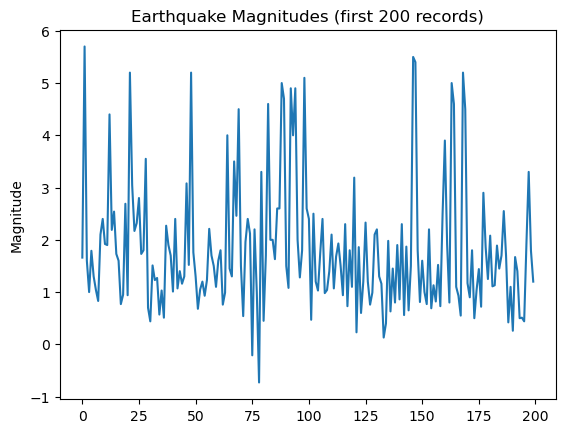

In [207]:
# Line plot: magnitude values (first 200 rows)
eq.head(200)['mag'].plot(title='Earthquake Magnitudes (first 200 records)')
plt.ylabel('Magnitude')
plt.show()

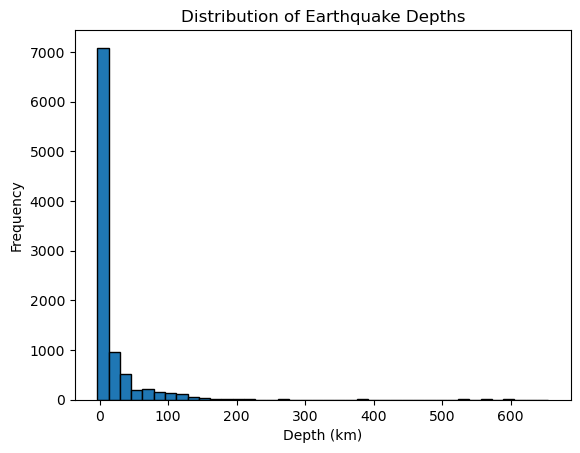

In [208]:
# Histogram of earthquake depths
eq['depth'].plot.hist(bins=40, edgecolor='black', title='Distribution of Earthquake Depths')
plt.xlabel('Depth (km)')
plt.show()

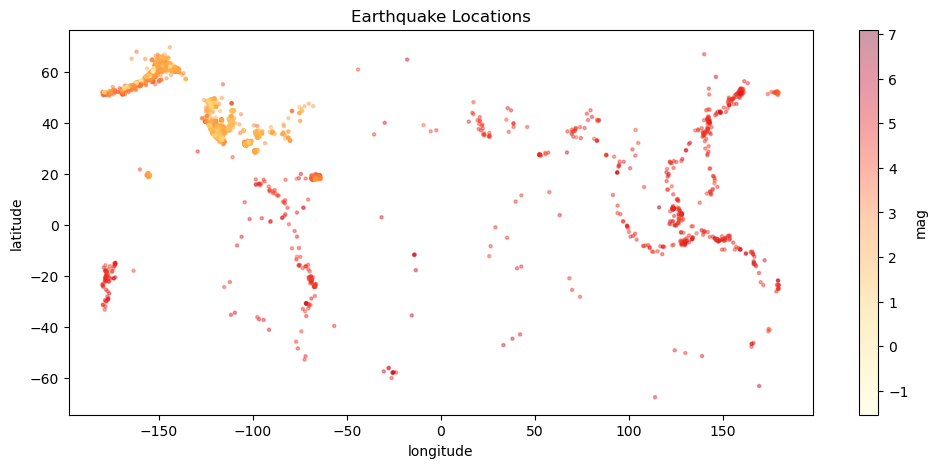

In [209]:
# Scatter plot of earthquake locations
eq.plot(kind='scatter', x='longitude', y='latitude',
        c='mag', cmap='YlOrRd', alpha=0.4, s=5,
        figsize=(12, 5), title='Earthquake Locations')
plt.show()

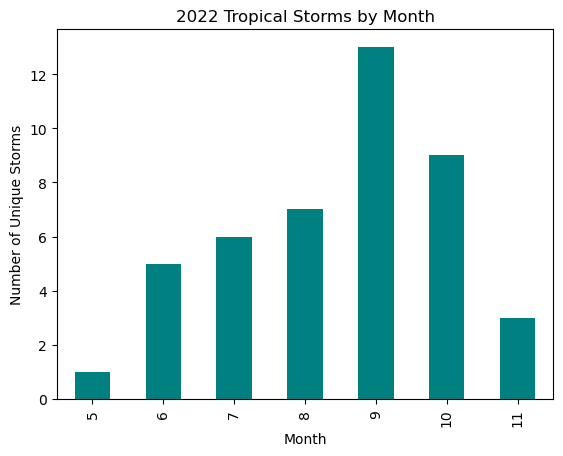

In [210]:
# Bar chart: storms per month from hurricane data
hur.groupby('month')['SID'].nunique().plot(kind='bar', color='teal',
    title='2022 Tropical Storms by Month')
plt.ylabel('Number of Unique Storms')
plt.xlabel('Month')
plt.show()

### Exercise 2 — Explore the LA Crime Data

Use the LA crime dataset you imported in Exercise 1 to answer the following questions. If you have not imported it yet, do so now with `pd.read_csv('LA_2020_Theft.csv')`.  Please feel free to use AI tools like ChatGPT, Claude or Gemini to complete this assignment.

1. How many rows and columns does the dataset have? (Use `.shape`)
2. What are the column names? (Use `.columns`)
3. What data types are present? (Use `.dtypes` or `.info()`)
4. What is the most common crime description? (Try `.value_counts()` on the crime description column)
5. Create a histogram of victim ages.

In [212]:
# Your code here


## 6. Manipulating and Transforming Data

Raw data almost never comes in the exact format you need. Before performing analysis or feeding data into a model, you will need to **clean and transform** it. This is often called **data wrangling** or **data munging**, and it is the step where you will spend most of your time.

In this section we will cover the most essential manipulation operations:

| Operation | Method |
|---|---|
| Convert data types | `.astype()`, `pd.to_datetime()` |
| String manipulation | `.str.lower()`, `.str.replace()`, `.str.contains()` |
| Handle missing values | `.fillna()`, `.dropna()` |
| Create new columns | `df['new'] = ...` |
| Drop columns | `.drop('col', axis=1)` |
| Sort data | `.sort_values()` |
| Shuffle / sample rows | `.sample()` |
| Reset the index | `.reset_index()` |
| Apply a custom function | `.apply()` |

Let's work through each one using our spatial datasets.

### Converting Data Types

One of the most common data preparation tasks is converting a column to the correct type. For example, the `time` column in our earthquake data was loaded as a generic `object` (string) rather than a proper datetime. Converting it enables time‑based filtering, sorting, and plotting.

Use `pd.to_datetime()` for dates and `.astype()` for other conversions (e.g., string to integer).

In [213]:
# Check the current type of the 'time' column
print(f"Before: {eq['time'].dtype}")

# Convert to datetime
eq['time'] = pd.to_datetime(eq['time'])

print(f"After:  {eq['time'].dtype}")
eq[['time', 'mag']].head()

Before: object
After:  datetime64[ns, UTC]


,time,mag
0,2026-02-26 05:10:55.471000+00:00,1.66
1,2026-02-26 04:59:03.922000+00:00,5.70
2,2026-02-26 04:54:33.885000+00:00,1.60
3,2026-02-26 04:24:59.410000+00:00,1.00
4,2026-02-26 04:22:52.820000+00:00,1.79


Now that `time` is a proper datetime, we can do things like extract the hour, filter by date range, or sort chronologically.

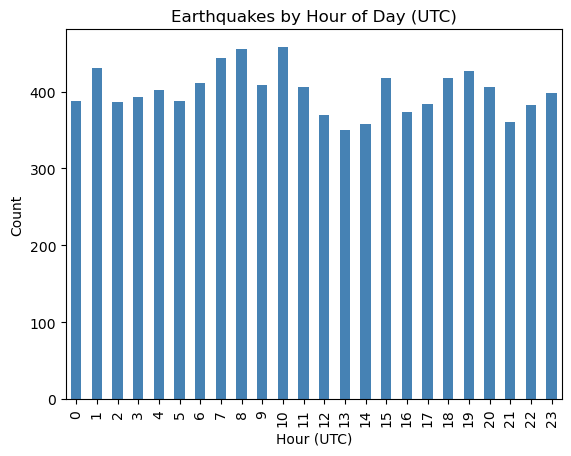

In [214]:
# Extract the hour of each earthquake
eq['hour'] = eq['time'].dt.hour

# How many earthquakes per hour of the day?
eq['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue',
    title='Earthquakes by Hour of Day (UTC)')
plt.xlabel('Hour (UTC)')
plt.ylabel('Count')
plt.show()

### String Manipulation with `.str`

pandas exposes all of Python's string methods through the `.str` accessor. This means you can call `.lower()`, `.upper()`, `.replace()`, `.contains()`, `.split()`, and more on an entire column at once.

This is very useful for cleaning up messy text data — for example, standardizing place names or extracting part of a text field.

In [215]:
# Lowercase all values in the 'place' column
eq['place'].str.lower().head()

0            67 km n of rachel, nevada
1    176 km sse of vilyuchinsk, russia
2           26 km w of central, alaska
3                   4 km w of cobb, ca
4            15 km se of boonville, ca
Name: place, dtype: object

In [216]:
# Check if the place description contains 'california'
ca_quakes = eq[eq['place'].str.contains('California', case=False, na=False)]
print(f"Earthquakes mentioning California: {len(ca_quakes):,}")
ca_quakes[['time', 'place', 'mag']].head()

Earthquakes mentioning California: 15


,time,place,mag
777,2026-02-23 07:09:14.074000+00:00,"33 km NE of Keeler, California",1.78
1531,2026-02-20 20:14:59.532000+00:00,"10 km NW of Corcoran, California",2.50
1657,2026-02-20 08:03:37.752000+00:00,"18 km SSW of Tecopa, California",1.78
2381,2026-02-17 17:27:43.953000+00:00,"11 km NE of Big Pine, California",2.32
2772,2026-02-16 09:29:59.348000+00:00,"15 km NE of Big Pine, California",1.51


**Important:** Notice that we used `case=False` to make the search case‑insensitive, and `na=False` to avoid errors on rows where the `place` column might be `NaN` (missing).

### Handling Missing Values — `.fillna()` and `.dropna()`

Real‑world datasets almost always have missing values. In pandas, missing values are represented as `NaN` (Not a Number).

You have two main strategies:

1. **Fill** the missing values with a replacement (e.g., the column mean, median, zero, or a placeholder string) using `.fillna()`.
2. **Drop** the rows (or columns) that contain missing values using `.dropna()`.

The right choice depends on the situation. If only a few rows are missing a value in a non‑critical column, dropping them may be fine. But if a large fraction of rows are affected, filling with a sensible default is often better.

Let's see how many missing values our earthquake data has.

In [217]:
# Count missing values per column
missing = eq.isnull().sum()
missing[missing > 0]  # show only columns with at least one missing value

mag                  1
magType              1
dmin                14
horizontalError    493
depthError          76
magError            36
magNst               3
dtype: int64

In [218]:
# Fill missing magnitude values with the column median
median_mag = eq['mag'].median()
print(f"Median magnitude: {median_mag}")

eq['mag'] = eq['mag'].fillna(median_mag)

# Verify
print(f"Missing 'mag' values after fill: {eq['mag'].isnull().sum()}")

Median magnitude: 1.6
Missing 'mag' values after fill: 0


### A Note on `inplace`

Many pandas methods have an `inplace` parameter:

- `inplace=False` (the **default**) — returns a **new** DataFrame/Series; the original is unchanged.
- `inplace=True` — modifies the original DataFrame/Series directly and returns `None`.

Modern pandas best practice is to **avoid** `inplace=True` and instead reassign:

```python
# Preferred
df = df.dropna()

# Also works, but less readable and being deprecated for some methods
df.dropna(inplace=True)
```

Let's demonstrate with `.dropna()`.

In [219]:
# Drop all rows that have ANY missing value
eq_clean = eq.dropna()  # returns a new DataFrame; eq is unchanged

print(f"Before dropna: {len(eq):,} rows")
print(f"After dropna:  {len(eq_clean):,} rows")
print(f"Rows removed:  {len(eq) - len(eq_clean):,}")

Before dropna: 9,616 rows
After dropna:  9,001 rows
Rows removed:  615


### Creating New Columns

One of the most common data manipulation tasks is **creating new columns** derived from existing ones. This is sometimes called **feature engineering** — enriching your dataset with additional information.

There are several ways to add a column:

1. **From a constant value** — e.g., `df['country'] = 'USA'`
2. **From a calculation on other columns** — e.g., `df['depth_miles'] = df['depth'] * 0.621`
3. **From a list or Series** — e.g., `df['category'] = my_list`

In [220]:
# Create a new column: depth in miles (1 km ≈ 0.621 miles)
eq['depth_miles'] = eq['depth'] * 0.621371
eq[['depth', 'depth_miles']].head()

,depth,depth_miles
0,7.3182,4.547317
1,10.0000,6.213710
2,6.7000,4.163186
3,2.1500,1.335948
4,4.7700,2.963940


In [221]:
# Create a new column: magnitude category
def classify_magnitude(mag):
    if mag < 2.0:
        return 'Micro'
    elif mag < 4.0:
        return 'Minor'
    elif mag < 5.0:
        return 'Light'
    elif mag < 6.0:
        return 'Moderate'
    else:
        return 'Strong+'

eq['mag_category'] = eq['mag'].apply(classify_magnitude)
eq['mag_category'].value_counts()

mag_category
Micro       6635
Minor       2169
Light        663
Moderate     139
Strong+       10
Name: count, dtype: int64

In [222]:
# Create a constant column
eq['data_source'] = 'USGS'
eq[['place', 'mag', 'data_source']].head()

,place,mag,data_source
0,"67 km N of Rachel, Nevada",1.66,USGS
1,"176 km SSE of Vilyuchinsk, Russia",5.70,USGS
2,"26 km W of Central, Alaska",1.60,USGS
3,"4 km W of Cobb, CA",1.00,USGS
4,"15 km SE of Boonville, CA",1.79,USGS


### Dropping Columns

If you create a column that turns out not to be useful, or if you want to simplify your DataFrame before exporting, you can remove columns with `.drop()`.

The `axis=1` parameter tells pandas you want to drop a **column** (axis 0 = rows, axis 1 = columns).

In [223]:
# Drop the 'data_source' column we just created
eq = eq.drop('data_source', axis=1)

# Verify it's gone
'data_source' in eq.columns

False

### Sorting Data

You can sort a DataFrame by one or more columns using `.sort_values()`. This is useful for finding the largest earthquakes, the most recent events, or the deepest quakes.

In [224]:
# Sort by magnitude, largest first
eq.sort_values('mag', ascending=False).head(10)[['time', 'place', 'mag', 'depth']]

,time,place,mag,depth
991,2026-02-22 16:57:46.240000+00:00,"55 km NNW of Kota Belud, Malaysia",7.1,619.849
3417,2026-02-14 02:27:37.951000+00:00,"53 km WNW of Port-Olry, Vanuatu",6.4,10.000
4013,2026-02-12 13:34:31.114000+00:00,"32 km SW of Ovalle, Chile",6.2,36.885
4628,2026-02-10 20:44:52.774000+00:00,Fiji region,6.2,510.944
6782,2026-02-04 10:39:28.490000+00:00,"Kermadec Islands, New Zealand",6.1,167.000
832,2026-02-23 05:11:48.783000+00:00,"93 km SW of Nikolski, Alaska",6.1,14.000
1082,2026-02-22 07:43:26.645000+00:00,south of the Fiji Islands,6.0,653.785
2624,2026-02-16 21:42:52.597000+00:00,"86 km ESE of Ozernovskiy, Russia",6.0,43.000
2980,2026-02-15 15:58:48.801000+00:00,"284 km SSW of Severo-Kuril’sk, Russia",6.0,54.981
8777,2026-01-29 07:30:35.031000+00:00,South Sandwich Islands region,6.0,27.000


In [225]:
# Sort by time, most recent first
eq.sort_values('time', ascending=False).head()[['time', 'place', 'mag']]

,time,place,mag
0,2026-02-26 05:10:55.471000+00:00,"67 km N of Rachel, Nevada",1.66
1,2026-02-26 04:59:03.922000+00:00,"176 km SSE of Vilyuchinsk, Russia",5.70
2,2026-02-26 04:54:33.885000+00:00,"26 km W of Central, Alaska",1.60
3,2026-02-26 04:24:59.410000+00:00,"4 km W of Cobb, CA",1.00
4,2026-02-26 04:22:52.820000+00:00,"15 km SE of Boonville, CA",1.79


### Sampling and Shuffling Rows

The `.sample()` method randomly selects rows from a DataFrame. This is useful for:

- **Quick testing** — if your dataset has millions of rows, work with a random sample first to speed up experimentation.
- **Shuffling** — `df.sample(frac=1)` returns all rows in random order.
- **Splitting data** — take a random subset for training vs. testing.

The `frac` parameter specifies the fraction of rows to return (1.0 = 100%). The `n` parameter specifies an exact number of rows.

In [226]:
# Random sample of 5 earthquakes
eq.sample(n=5)[['time', 'place', 'mag', 'depth']]

,time,place,mag,depth
5826,2026-02-07 10:33:23.880000+00:00,"1 km NNW of Maple Valley, Washington",1.32,15.66
6968,2026-02-03 20:48:37.937000+00:00,"119 km N of Yakutat, Alaska",1.90,4.80
9156,2026-01-28 07:59:44.010000+00:00,"10 km NW of The Geysers, CA",0.71,1.75
2187,2026-02-18 08:51:18.410000+00:00,"6 km WNW of Cobb, CA",0.58,1.68
583,2026-02-23 20:02:09.199000+00:00,"10 km ESE of Loco, Oklahoma",2.01,5.93


In [227]:
# Shuffle all rows (frac=1 = 100%)
eq_shuffled = eq.sample(frac=1)
print(f"Original index order: {list(eq.index[:5])}")
print(f"Shuffled index order: {list(eq_shuffled.index[:5])}")

Original index order: [0, 1, 2, 3, 4]
Shuffled index order: [8967, 5618, 7144, 622, 2827]


### Resetting the Index

After shuffling, filtering, or dropping rows, the index may no longer be a clean 0, 1, 2, … sequence. Use `.reset_index(drop=True)` to restore it.

The `drop=True` parameter prevents the old index from being added as a new column.

In [228]:
# Reset the index after shuffling
eq_shuffled = eq_shuffled.reset_index(drop=True)
eq_shuffled.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,horizontalError,depthError,magError,magNst,status,locationSource,magSource,hour,depth_miles,mag_category
0,2026-01-28 18:59:30.483000+00:00,60.719000,-147.587000,11.50,1.90,ml,19,64,0.30000,0.50,...,3.60,3.1141,0.100,6.0,reviewed,ak,ak,18,7.145766,Micro
1,2026-02-08 01:38:50.890000+00:00,36.051167,-120.615167,5.72,1.84,md,49,62,0.02338,0.10,...,0.22,0.3200,0.259,33.0,reviewed,nc,nc,1,3.554242,Micro
2,2026-02-03 04:40:24.120000+00:00,18.036500,-68.625000,75.00,3.61,md,17,245,0.53600,0.48,...,4.11,4.0900,0.040,11.0,reviewed,pr,pr,4,46.602825,Minor
3,2026-02-23 17:05:20.010000+00:00,55.978300,-150.052300,10.00,3.10,ml,34,205,2.28100,0.59,...,4.29,2.0130,0.062,34.0,reviewed,us,us,17,6.213710,Minor
4,2026-02-16 05:07:09.857000+00:00,60.351000,-139.357000,1.60,1.90,ml,13,120,0.50000,0.70,...,6.40,4.5407,0.300,5.0,reviewed,ak,ak,5,0.994194,Micro


### Applying Custom Functions with `.apply()`

The `.apply()` method lets you run any Python function on every value in a column (or every row in a DataFrame). This is how you perform custom transformations that pandas does not have a built‑in method for.

You can pass a **named function** or a **lambda function** (an anonymous one‑liner).

A lambda function has the syntax: `lambda x: <expression>`, where `x` is each value in the column.

For example, let's convert earthquake depth from kilometers to feet (1 km ≈ 3,280.84 feet).

In [229]:
# Convert depth from km to feet using a lambda function
eq['depth_feet'] = eq['depth'].apply(lambda x: x * 3280.84)
eq[['depth', 'depth_miles', 'depth_feet']].head()

,depth,depth_miles,depth_feet
0,7.3182,4.547317,24009.843288
1,10.0000,6.213710,32808.400000
2,6.7000,4.163186,21981.628000
3,2.1500,1.335948,7053.806313
4,4.7700,2.963940,15649.606737


We already used `.apply()` with a named function earlier when we created the `mag_category` column. Both approaches are valid — use a named function when the logic is more than one line, and a lambda when it is a simple expression.

### Putting It All Together — Hurricane Data Example

Let's apply several manipulation techniques to the hurricane dataset in sequence. This is a realistic workflow where you chain multiple operations to prepare data for analysis.

In [230]:
# Reload hurricane data
hur = pd.read_csv('hurricanes.csv')

# 1. Create a proper date column
hur['date'] = pd.to_datetime(hur[['year', 'month', 'day']])

# 2. Convert wind speed from knots to mph (1 knot ≈ 1.151 mph)
hur['wind_mph'] = hur['USA_WIND'].apply(lambda x: x * 1.151 if pd.notna(x) else x)

# 3. Classify storm intensity
def classify_storm(wind_kt):
    """Classify storm based on sustained wind speed in knots."""
    if pd.isna(wind_kt):
        return 'Unknown'
    elif wind_kt < 34:
        return 'Tropical Depression'
    elif wind_kt < 64:
        return 'Tropical Storm'
    elif wind_kt < 96:
        return 'Cat 1-2 Hurricane'
    else:
        return 'Major Hurricane (Cat 3+)'

hur['intensity'] = hur['USA_WIND'].apply(classify_storm)

# 4. View the results
hur[['NAME', 'date', 'USA_WIND', 'wind_mph', 'intensity']].head(10)

,NAME,date,USA_WIND,wind_mph,intensity
0,Agatha,2022-05-27,25,28.775,Tropical Depression
1,Agatha,2022-05-27,28,32.228,Tropical Depression
2,Agatha,2022-05-28,30,34.530,Tropical Depression
3,Agatha,2022-05-28,33,37.983,Tropical Depression
4,Agatha,2022-05-28,35,40.285,Tropical Storm
5,Agatha,2022-05-28,38,43.738,Tropical Storm
6,Agatha,2022-05-28,40,46.040,Tropical Storm
7,Agatha,2022-05-28,45,51.795,Tropical Storm
8,Agatha,2022-05-28,50,57.550,Tropical Storm
9,Agatha,2022-05-28,53,61.003,Tropical Storm


In [231]:
# 5. Count observations by intensity category
hur['intensity'].value_counts()

intensity
Tropical Storm              856
Tropical Depression         674
Cat 1-2 Hurricane           319
Major Hurricane (Cat 3+)     90
Name: count, dtype: int64

In [232]:
# 6. Find the peak wind speed for each named storm
peak_winds = hur.groupby('NAME')['USA_WIND'].max().sort_values(ascending=False)
print("Peak wind speeds by storm (knots):")
peak_winds.head(10)

Peak wind speeds by storm (knots):


NAME
Ian       140
Darby     120
Fiona     120
Roslyn    115
Orlene    115
Bonnie    100
Earl       95
Agatha     95
Kay        85
Frank      80
Name: USA_WIND, dtype: int64

### Exercise 3 — Manipulate the LA Crime Data

Using the LA crime dataset (`LA_2020_Theft.csv`), practice the following operations:

1. Check for missing values using `.isnull().sum()`.
2. Drop any rows that are missing geographic coordinates (latitude/longitude columns).
3. Create a new column that classifies each crime by the time of day it occurred (e.g., Morning, Afternoon, Evening, Night).
4. Use `.groupby()` to count the number of crimes per area name.
5. Sort the result from step 4 to find the area with the most reported thefts.

**Hint:** You may need to examine the column names with `.columns` first to identify the correct field names.

In [233]:
# Your code here


## Summary

Congratulations — you have covered all of the core pandas skills needed for spatial data analysis! Here is a recap of everything we covered:

### Core Data Structures
- **Series** — a single column of data, created with `pd.Series()`.
- **DataFrame** — a table of rows and columns, created with `pd.DataFrame()` or imported from a file.

### Importing & Exporting
- `pd.read_csv()` — read CSV files from a local path or URL.
- `.to_csv()` / `.to_excel()` — export DataFrames to files.

### Describing & Exploring
- `.dtypes` — data types of each column.
- `.describe()` — summary statistics for numeric columns.
- `.info()` — row counts, missing values, and memory usage.
- `.columns`, `.index`, `len(df)` — structural information.

### Viewing & Selecting
- `.head()`, `.tail()` — preview rows.
- `df['column']` — select a column.
- `.loc[]` / `.iloc[]` — label‑based vs. position‑based selection.
- Boolean indexing — `df[df['col'] > value]` to filter rows.
- `.groupby()` — split‑apply‑combine aggregation.
- `pd.crosstab()` — frequency tables for categorical columns.

### Manipulating & Transforming
- `pd.to_datetime()` / `.astype()` — convert data types.
- `.str` accessor — string operations on text columns.
- `.fillna()` / `.dropna()` — handle missing values.
- `df['new_col'] = ...` — create new columns.
- `.drop('col', axis=1)` — remove columns.
- `.sort_values()` — sort by one or more columns.
- `.sample()` — random sampling and shuffling.
- `.reset_index()` — restore a clean integer index.
- `.apply()` — apply a custom function to every value.

### Quick Plotting
- `.plot()`, `.plot.hist()`, `.plot.bar()` — fast visualizations directly from DataFrames.

### Extra Resources

- [pandas documentation](https://pandas.pydata.org/pandas-docs/stable/) — the complete reference.
- [10 Minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html) — an excellent quick‑start guide.
- [pandas cheat sheet (PDF)](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) — a printable reference card.
- [Stack Overflow — pandas tag](https://stackoverflow.com/questions/tagged/pandas) — thousands of answered questions.